In [11]:
import numpy as np
import matplotlib.pyplot as plt

import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import LammpsWriter as LammpsWriter
import Run_anneal as Run_anneal
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Monte Carlo Sweeps: 100%|██████████| 100000/100000 [00:01<00:00, 68725.18it/s]


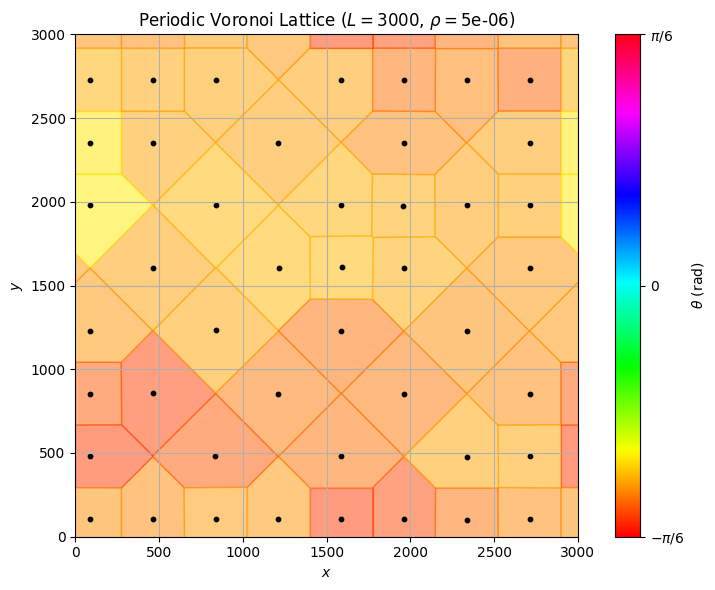

In [39]:
T = 80
L = 3000
rho = 0.000005
alpha = 2.36
beta_RS = -0.12
epsilon = 0

vor = Voronoi.PeriodicVoronoi(L, rho)

thetas, _ = MonteCarlo.monte_carlo(vor.theta, vor.adj_i, vor.adj_j, vor.adj_length, 1/T, epsilon, rho, alpha, beta_RS, 100_000)
vor.theta = thetas
vor.plot()
plt.show()

graphene = Graphene.GrapheneCrystal(vor, a=1.42)
# graphene.plot_atoms()
# plt.show()
# graphene.plot_bonds()
# plt.show()


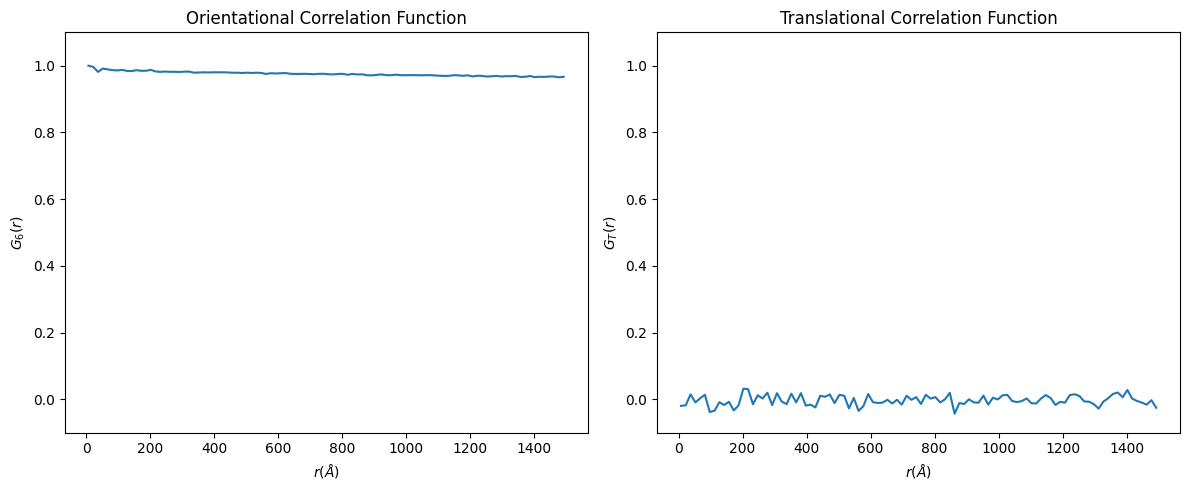

In [40]:
bin_centers, G6, GT = graphene.compute_observables()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(bin_centers, G6)
ax1.set_xlabel(r'$r (\AA)$')
ax1.set_ylabel(r'$G_6(r)$')
ax1.set_title('Orientational Correlation Function')
ax1.set_ylim(-0.1, 1.1)

ax2.plot(bin_centers, GT)
ax2.set_xlabel(r'$r (\AA)$')
ax2.set_ylabel(r'$G_T(r)$')
ax2.set_title('Translational Correlation Function')
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()